# Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import geopandas as gpd
import folium
from folium.plugins import HeatMap
import pydeck as pdk
import hashlib


import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from shapely import wkt

# Loading DF

In [2]:
pre_norm_df_final = pd.read_csv('..\\Data\\display_rdy_STREET_4.csv', low_memory=False)
norm_df = pd.read_csv('..\\Data\\norm_STREET_5.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

# PCA

In [3]:
# # Run PCA and automatically find the optimal components
# # We initially set the n_components to 85% in order to keep 85% of the original information and lose only 15%
# pca_optimal = PCA(n_components=0.85, random_state=42)
# X_pca = pca_optimal.fit_transform(X_scaled)

# # Extract number of needed components
# best_n = pca_optimal.n_components_
# print(f"To retain 85% of the data's variance, PCA selected {best_n} components.")

# # Generate PCA columns
# pca_columns = [f"PCA_{i}" for i in range(1, best_n + 1)]

# Clustering KMEANS

In [3]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Cluster Counts:\n", labels.value_counts())


In [4]:
# Drop incident zip column
Features = norm_df.drop("Street_Name", axis=1)

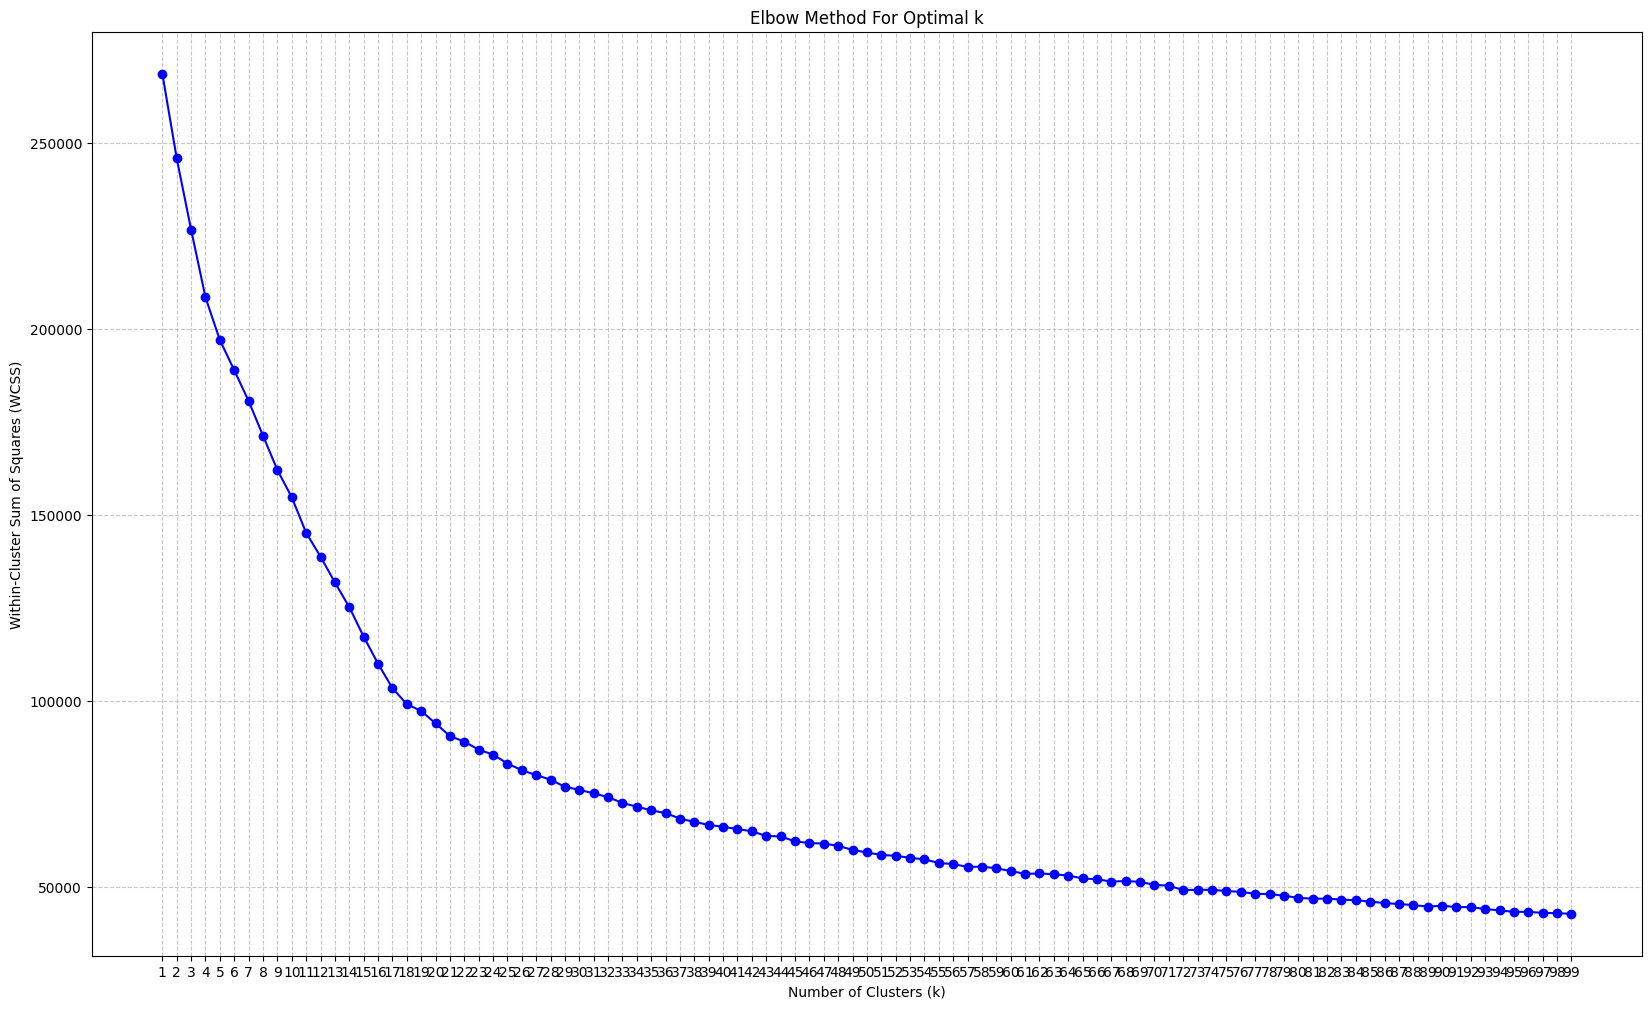

In [5]:
# Calculate WCSS (Within-Cluster Sum of Squares ) for different values of k
wcss = []
k_range = range(1, 100) # Testing k=1 through k=100 

for k in k_range:
    # random_state ensures reproducible results
    # n_init=10 suppresses future warnings in scikit-learn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Features)
    wcss.append(kmeans.inertia_)

# 4. Plot the Elbow Curve
plt.figure(figsize=(20, 12))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [7]:
kmeans = KMeans(n_clusters=20,random_state=42, n_init="auto").fit(Features)
labels = pd.Series(kmeans.labels_)
pre_norm_df_final["Cluster"] = labels
output(labels)

The labels:
 0        18
1         2
2        13
3         3
4        18
         ..
11188    18
11189     0
11190     2
11191    13
11192    11
Length: 11193, dtype: int32
Cluster Counts:
 13    2347
18    2267
11    1685
1      844
0      731
2      720
8      479
15     427
4      294
14     272
10     226
3      219
17     190
5      137
9      123
19     115
6       85
16      20
7       11
12       1
Name: count, dtype: int64


In [34]:
# Check how many streets are in each of the 19 clusters
val_count_sorted = pre_norm_df_final['Cluster'].value_counts().sort_index()
val_count_sorted

Cluster
0      731
1      844
2      720
3      219
4      294
5      137
6       85
7       11
8      479
9      123
10     226
11    1685
12    2347
13     272
14     427
15      20
16     190
17    2267
18     115
19       1
Name: count, dtype: int64

In [35]:
# Define the tiny outlier clusters you want to push to the end
outlier_clusters = singleton_labels = val_count_sorted[val_count_sorted == 1].index.tolist()

# Get a list of all current clusters in your dataframe, sorted numerically
current_clusters = sorted(pre_norm_df_final['Cluster'].dropna().unique())

# Separate the "main" clusters from the "outlier" clusters
main_clusters = [c for c in current_clusters if c not in outlier_clusters]
outliers_present = [c for c in outlier_clusters if c in current_clusters]

# Create a new ordered list: Main clusters first, followed by outliers at the end
new_cluster_order = main_clusters + outliers_present

# Create a mapping dictionary {old_id: new_id}
# This automatically assigns 0, 1, 2... etc.
# Your main clusters will become 0 to 10, and your outliers will become 11, 12, 13, 14.
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(new_cluster_order)}

# Let's print the mapping so you can verify it worked exactly as you wanted
print("Here is how the clusters are being renumbered:")
for old, new in cluster_mapping.items():
    print(f"Old Cluster {old} --> New Cluster {new}")

# Apply the mapping to overwrite the old numbers
pre_norm_df_final['Cluster'] = pre_norm_df_final['Cluster'].map(cluster_mapping)

Here is how the clusters are being renumbered:
Old Cluster 0 --> New Cluster 0
Old Cluster 1 --> New Cluster 1
Old Cluster 2 --> New Cluster 2
Old Cluster 3 --> New Cluster 3
Old Cluster 4 --> New Cluster 4
Old Cluster 5 --> New Cluster 5
Old Cluster 6 --> New Cluster 6
Old Cluster 7 --> New Cluster 7
Old Cluster 8 --> New Cluster 8
Old Cluster 9 --> New Cluster 9
Old Cluster 10 --> New Cluster 10
Old Cluster 11 --> New Cluster 11
Old Cluster 12 --> New Cluster 12
Old Cluster 13 --> New Cluster 13
Old Cluster 14 --> New Cluster 14
Old Cluster 15 --> New Cluster 15
Old Cluster 16 --> New Cluster 16
Old Cluster 17 --> New Cluster 17
Old Cluster 18 --> New Cluster 18
Old Cluster 19 --> New Cluster 19


Merging clusters with the map...
Drawing the clustered streets...


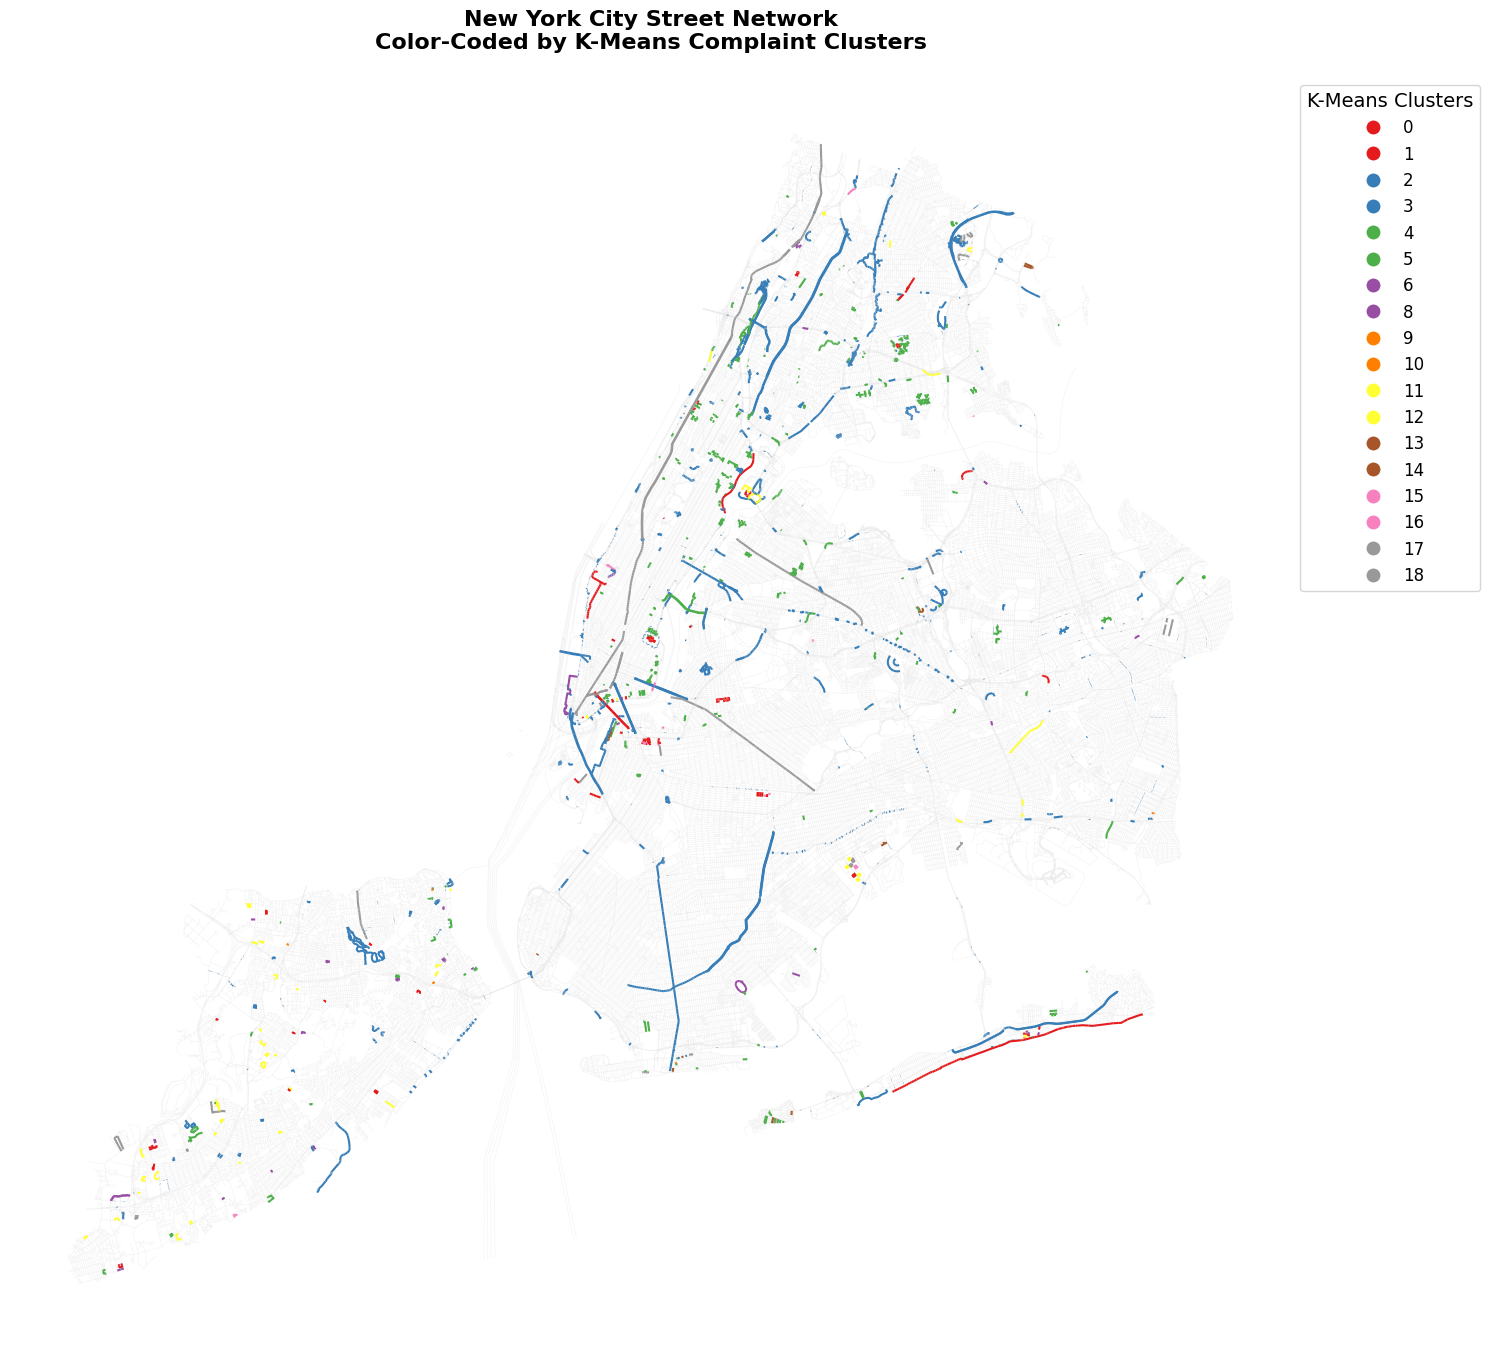

In [48]:
print("Merging clusters with the map...")
joined_map_gdf = streets_projected.merge(
    pre_norm_df_final[['Street_Name', 'Cluster']], 
    left_on='full_street_name', 
    right_on='Street_Name', 
    how='inner'
)

fig, ax = plt.subplots(figsize=(15, 15))

# === THE GHOST LAYER ===
# This draws every street in light gray so you can see the actual city structure
streets_projected.plot(ax=ax, color='#EAEAEA', linewidth=0.5, alpha=0.5)

print("Drawing the clustered streets...")
joined_map_gdf.plot(
    column='Cluster',
    cmap='Set1',          
    linewidth=1.5,
    categorical=True,      
    legend=True,
    ax=ax,
    legend_kwds={
        'title': 'K-Means Clusters',
        'loc': 'upper left',
        'bbox_to_anchor': (1, 1), 
        'fontsize': 12,
        'title_fontsize': 14
    }
)

ax.set_axis_off()
plt.title("New York City Street Network\nColor-Coded by K-Means Complaint Clusters", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [14]:
pre_norm_df_final

,Street_Name,Total_Complaints,Weekend_Ratio,Night_Complaint_Pct,Animals_and_Pets_Pct,Construction_and_DOB_Pct,Health_and_Environmental_Safety_Pct,Housing_and_Building_Maintenance_Pct,Noise_Pct,Other/Misc_CType_Pct,...,Median_Resolution_Time,Commercial_and_Retail_Pct,Infrastructure_and_Building_Components_Pct,"Institutions,_Health_and_Services_Pct",Other/Misc_LType_Pct,Public_Spaces_and_Outdoors_Pct,Residential_and_Mixed_Use_Pct,Street_and_Transportation_Pct,Agency_Diversity,Cluster
0,1 AVENUE,10715,24.181055,19.001400,1.325245,1.185254,5.076995,13.980401,24.759683,7.214186,...,10.200,11.731218,0.10266,0.093327,15.781615,2.967802,24.862343,44.461036,14,17
1,1 AVENUE LOOP,16,18.750000,0.000000,0.000000,0.000000,12.500000,0.000000,0.000000,0.000000,...,8.125,0.000000,0.00000,0.000000,100.000000,0.000000,0.000000,0.000000,2,2
2,1 COURT,14,28.571429,0.000000,14.285714,7.142857,7.142857,0.000000,0.000000,7.142857,...,35.690,0.000000,0.00000,0.000000,21.428571,0.000000,7.142857,71.428571,5,12
3,1 PARK,1,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,...,105.000,0.000000,0.00000,0.000000,0.000000,0.000000,100.000000,0.000000,1,3
4,1 PLACE,268,23.507463,9.328358,0.000000,3.731343,5.970149,3.731343,10.447761,5.597015,...,1.460,0.000000,0.00000,0.000000,20.522388,0.000000,9.701493,69.776119,10,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11188,ZOE STREET,40,32.500000,15.000000,2.500000,2.500000,22.500000,22.500000,10.000000,2.500000,...,22.305,2.500000,0.00000,0.000000,30.000000,0.000000,32.500000,35.000000,9,17
11189,ZOLLER ROAD,58,31.034483,32.758621,0.000000,1.724138,22.413793,3.448276,48.275862,3.448276,...,1.355,0.000000,0.00000,0.000000,53.448276,0.000000,36.206897,10.344828,7,0
11190,ZOO BRG,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,24.880,0.000000,0.00000,0.000000,100.000000,0.000000,0.000000,0.000000,1,2
11191,ZULETTE AVENUE,132,28.787879,11.363636,4.545455,1.515152,6.060606,0.000000,4.545455,6.818182,...,5.245,0.000000,0.00000,0.000000,21.969697,0.000000,3.787879,74.242424,7,12


In [38]:
# Extract the centroids from your fitted model
centroids = kmeans.cluster_centers_

# Convert to a DataFrame for readability
# Note: This assumes 'Features' is a Pandas DataFrame.
# If 'Features' is a numpy array, replace 'Features.columns' with a list of your feature names.
centroid_df = pd.DataFrame(centroids, columns=Features.columns)
centroid_df.index.name = 'Cluster'

# Function to extract and print the defining characteristics
def analyze_cluster_personas(centroid_dataframe, top_n=3):
    """
    Identifies the top N driving features for each cluster based on centroid values.
    """
    print(f"--- Top {top_n} Defining 311 Complaints per Cluster ---\n")

    for cluster_id in range(len(centroid_dataframe)):
        # Isolate the centroid values for the current cluster
        cluster_profile = centroid_dataframe.iloc[cluster_id]

# Sort features from highest to lowest value to find the dominant ones
        top_features = cluster_profile.sort_values(ascending=False).head(top_n)

        print(f"Cluster {cluster_id}:")
        for feature, value in top_features.items():
            # 'value' is the mathematical center for this feature in this cluster
            print(f"  * {feature}: {value:.4f}")

        print("-" * 40)

# Run the analysis
# You can change top_n to see more or fewer defining features
analyze_cluster_personas(centroid_df, top_n=4)

--- Top 4 Defining 311 Complaints per Cluster ---

Cluster 0:
  * Noise_Pct: 2.2036
  * Residential_and_Mixed_Use_Pct: 0.8016
  * Weekend_Ratio: 0.7031
  * Night_Complaint_Pct: 0.5253
----------------------------------------
Cluster 1:
  * Housing_and_Building_Maintenance_Pct: 2.8642
  * Residential_and_Mixed_Use_Pct: 2.0608
  * Agency_Diversity: 0.8612
  * Total_Complaints: 0.3100
----------------------------------------
Cluster 2:
  * Street_and_Infrastructure_Pct: 2.9951
  * Other/Misc_LType_Pct: 2.6102
  * Median_Resolution_Time: 0.4293
  * Institutions,_Health_and_Services_Pct: -0.0497
----------------------------------------
Cluster 3:
  * Other/Misc_CType_Pct: 3.7441
  * Street_and_Transportation_Pct: 0.7565
  * Median_Resolution_Time: 0.2355
  * Taxi_and_For-Hire_Vehicles_Pct: 0.0254
----------------------------------------
Cluster 4:
  * Health_and_Environmental_Safety_Pct: 4.7463
  * Other/Misc_LType_Pct: 2.0726
  * Institutions,_Health_and_Services_Pct: -0.0454
  * Median_Re